## Alberi decisionali

In [15]:
import pandas as pd
from sklearn import tree #albero
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [5]:
data = pd.read_csv("./registro_utilizzo_giacca.csv")
data.head()

,temperatura,vel_vento,condizione
0,23.7,0.0,no giacca
1,5.3,7.6,giacca
2,19.8,0.0,no giacca
3,18.3,0.0,no giacca
4,12.3,9.0,giacca


In [7]:
data.columns

Index(['temperatura', 'vel_vento', 'condizione'], dtype='object')

In [8]:
feature = ['temperatura', 'vel_vento']
output = ["condizione"]

**Non** occore normalizzare i dati per gli alberi decisionali

In [10]:
X = data[feature].to_numpy()
y = data[output].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.3)

Gli alberi decisionali da un punto di vista informatico (TIPSIT 4) hanno queste caratteristiche:
 * Ogni nodo può avere al massimo due figli (Binari)
 * il nodo iniziale si chiama root o radice
 * I nodi terminali si chiamano foglie
 * negli alberi decisionali ogni nodo si chiama **nodo decisionale**
 * la profondità (O altezza) di un albero è il numero di collegamenti tra root e la foglia più lontana

In [19]:
albero = tree.DecisionTreeClassifier(max_depth = 2)
albero.fit(X_train, y_train) #l'addestramento è mooooooolto veloce

,criterion,'gini'
,splitter,'best'
,max_depth,2
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [20]:
albero.score(X_test, y_test)

0.8363636363636363

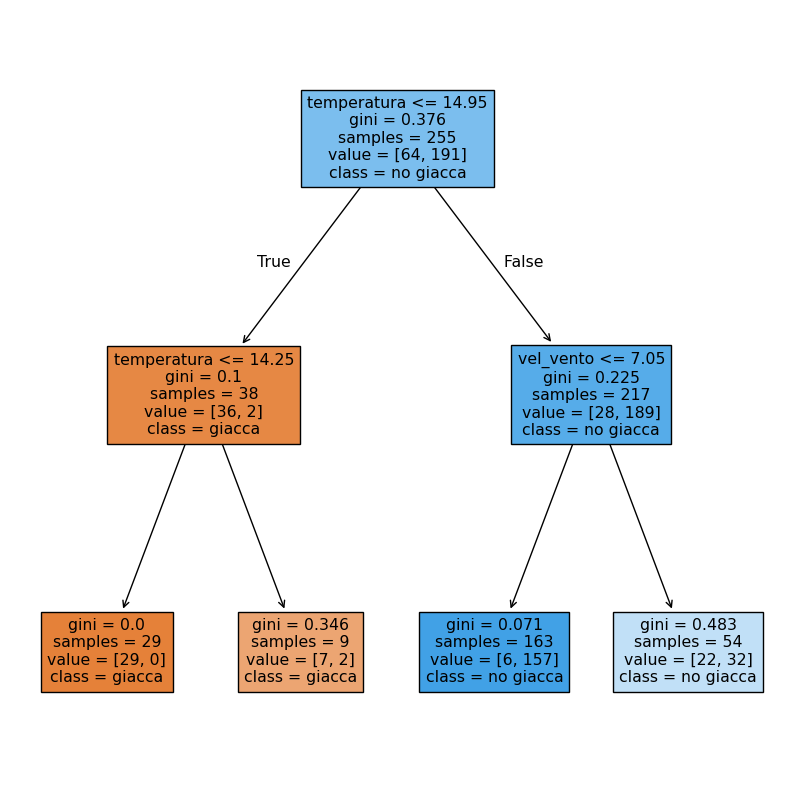

In [21]:
fig, ax = plt.subplots(figsize = (10,10))
tree.plot_tree(albero, ax=ax, feature_names=feature, class_names=albero.classes_, label="all", filled=True)#funzione dentro tree per fare il grafico dell'albero
plt.show()

1. Il grosso vantaggio degli alberi decisionali è che si tratta di algoritmi di machine learning **esplicabili** (Sono di totale comprensione)
2. C'è però un grosso svantaggio, gli alberi decisionali fanno **over-fitting**; imparano i dati di training "a memoria", cioè non sono in grado di generalizzare!
3. Un vantaggio è che richiedono pochissima potenza di calcolo per essere addestrati

# Foreste casuali

L'idea di base si rifà alla psicologia, in particolare al principio di **saggezza della folla**:
si crea una foresta di alberi (=insieme di alberi decisionali).

Come è possibile creare alberi diversi all'interno della foresta?

1. Ogni albero è addestrato su un sottoinsieme casuale della feature. Le feature sono estratte a caso dall'insieme delle feature senza sostituzione.
2. Ogni albero è addestrato su un sottoinsieme casuale dei campioni. I campioni (=sample) sono estratti a caso dall'insieme dei campioni con sostituzione.

Dare la conoscenza un po' a tutti gli alberi per avere una risposta

Come decide il valore di ouput una foresta? Ci sono due modi:
1. La foresta decide che il suo output è quello prodotto dalla maggioranza degli alberi (come nelle elezioni)
2. Ogni albero calcola la probabilità per i diversi output. La foresta calcola la media di queste probabilità: l'output della foresta è quello con probabilità più alta (Sklearn usa questo metodo, perché è il più potente)

le foreste casuali (= random forest) sono un esempio di **ensemble** learning, cioè apprendimento di insieme. (Non ho un algoritmo solo, ne ho tanti che imparano insieme).

In [24]:
from sklearn.ensemble import RandomForestClassifier

#Esempio di istanza:
rf = RandomForestClassifier(max_depth=3, n_estimators=50)
#ha tutti gli altri metodi come le reti neurali e le altre ai...